In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
from scipy.stats import unitary_group
import time
import matplotlib.pyplot as plt


# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')



def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod

# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q
    return q



In [24]:
def mkJumpLiouv(rate, dt, ldbldOp):

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)

    lindblads = [L1,L2]

    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))

    denseU=linalg.expm(G * dt)

    return denseU # to act on the vectorized density matrix of 2 qubits

def mkHaarLiouv(dt):
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    denseU=linalg.expm( -1j * H * dt)
    
    return denseU


def mkKrausOps(U):
    # takes outputs from mkLiouv
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))
    [eigVals, eigVecs] = linalg.eigh(X)

    krausOps=[]

    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]

    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row

    k_abs=np.array([[] for i in range(16)], dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4), dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    print(k_abs)

    return k_abs

def mkUnitaryKrausOps(layer, Nqubit, dt1, debug=False):

    allKs = {}
    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            # first unitary:
            krausOps = mkKrausOps(mkHaarLiouv(dt1))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = mkKrausOps(mkHaarLiouv(dt1))
            allKs[pos] = []

            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC

                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]
    return allKs


def mkUnitaryKrausOps_1(layer, Nqubit, debug=False):

    allKs = {}
    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            # first unitary:
            krausOps = [unitary_group.rvs(4)]
            allKs[pos] = []

            U_chain = chain(repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
            allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = [unitary_group.rvs(4)]
            allKs[pos] = []

            if pos < Nqubit-1:                
                U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC

                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]
    return allKs


# Just make a separate function for jumps:
def mkJumpKrausOps(layer, Nqubit, dt2, rate, ldbldOp, debug=False):       
    allKs = {}
    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            # first unitary:
            krausOps = mkKrausOps(mkJumpLiouv(rate, dt2, ldbldOp))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = mkKrausOps(mkJumpLiouv(rate, dt2, ldbldOp))
            allKs[pos] = []

            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC

                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]
    return allKs


# employ the faster Kraus sum
def evolveKrausU(allKs, rho, debug = False):

    Nqubit = int(np.log2(len(rho.toarray())))

    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()

    return newRho



def mkS_zMsm(probMsm, rho , debug = False):

    Nqubit = int(np.log2(len(rho.toarray())))
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2,
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)

        for (j,ms) in enumerate(msmSites):
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)

            if debug == True: print(proj_chain)

            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            if debug == True: print("projector", proj0p.shape, " rho", rho.shape)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())

            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob

            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            rho = testRho

    else:
        testRho = rho

    return testRho


def ptrace_rho(rho, elements):
    operator = rho
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    temp = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(temp.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
    operator = np.einsum(temp, indexarr)

    length = len(operator.shape)
    halflength = length//2

    if elements != []:
        operator = np.transpose(operator,[length-2,length-1]+list(range(0,length-2))) #cyclic permutation for toqito

    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))


def calcS(densityM, partiesToTraceOut):
    Ntot=int(np.log2(densityM.shape[0]))
    redRho = ptrace_rho(densityM, partiesToTraceOut)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S


def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity

def flatten_tensor_op(operator):
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))

#only works for tensor products of 2-state systems
def unflatten_tensor_op(operator):
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    return np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

def calcNegativity(densitymatx, transpose_indices):
    unflatrho = unflatten_tensor_op(densitymatx)
    transposer = list(range(len(unflatrho.shape)))
    for i in transpose_indices:
        transposer[2*i+1],transposer[2*i] = transposer[2*i],transposer[2*i+1]
    transposed = flatten_tensor_op(np.transpose(unflatrho,tuple(transposer)))
    return (np.trace(linalg.sqrtm(transposed.T.conj()@transposed))-1)/2


def combinedRoutine(initRho, Nqubit, rate, probMsm, dt1, dt2, jumpOp, steps, debug = False):
    rho = sparse.csr_matrix(reduce(sparse.kron, [initRho]*Nqubit))

    startTime = time.time()

    entropy1 = np.zeros(steps)
    entropy2 = np.zeros(steps)
    entropy_tot = np.zeros(steps)
    mutual_info = np.zeros(steps)
    purity = np.zeros(steps)
    negativity = np.zeros(steps)
 
    for s in range(steps):
        allKrausOps = mkUnitaryKrausOps(s, Nqubit, dt1, debug = False)
        rho = evolveKrausU(allKrausOps, rho)
        
        # second Jump,
        allKrausOps = mkJumpKrausOps(s, Nqubit,  dt2, rate, jumpOp, debug = False)
        rho = evolveKrausU(allKrausOps, rho)
        
        # third mk msm...
        rho = mkS_zMsm(p, rho)


        entropy1[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
        entropy2[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
        entropy_tot[s] = calcS(rho.toarray(), partiesToTraceOut = [])
        mutual_info[s] = entropy1[s] + entropy2[s] - entropy_tot[s]
        purity[s] = np.real(calcPurity(rho.toarray()))
        negativity[s] = calcNegativity(rho.toarray(), [n for n in range(Nqubit//2)])

    return entropy1, entropy2, entropy_tot, mutual_info, purity, negativity

def combinedRoutine_1(initRho, Nqubit, rate, probMsm, dt2, jumpOp, steps, debug = False):
    rho = sparse.csr_matrix(reduce(sparse.kron, [initRho]*Nqubit))

    startTime = time.time()

    entropy1 = np.zeros(steps)
    entropy2 = np.zeros(steps)
    entropy_tot = np.zeros(steps)
    mutual_info = np.zeros(steps)
    purity = np.zeros(steps)
    negativity = np.zeros(steps)
 
    for s in range(steps): 
        allKrausOps = mkUnitaryKrausOps_1(s, Nqubit, debug = False)
        rho = evolveKrausU(allKrausOps, rho)
        
        # second Jump,
        allKrausOps = mkJumpKrausOps(s, Nqubit,  dt2, rate, jumpOp, debug = False)
        rho = evolveKrausU(allKrausOps, rho)
        
        # third mk msm...
        rho = mkS_zMsm(p, rho)


        entropy1[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
        entropy2[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
        entropy_tot[s] = calcS(rho.toarray(), partiesToTraceOut = [])
        mutual_info[s] = entropy1[s] + entropy2[s] - entropy_tot[s]
        purity[s] = np.real(calcPurity(rho.toarray()))
        negativity[s] = calcNegativity(rho.toarray(), [n for n in range(Nqubit//2)])

    return entropy1, entropy2, entropy_tot, mutual_info, purity, negativity


def combinedRoutine_test(initRho, Nqubit, rate, probMs, dt2, jumpOp, steps, debug = False):
    rho = sparse.csr_matrix(reduce(sparse.kron, [initRho]*Nqubit))

    startTime = time.time()
    print('traj starts.')

    entropy1 = np.zeros(steps)
    entropy2 = np.zeros(steps)
    entropy_tot = np.zeros(steps)
    mutual_info = np.zeros(steps)
    purity = np.zeros(steps)
    negativity = np.zeros(steps)

    # pre-make all the Kraus operators so it's not calculated all the time
    evenJumpKrausOps = mkJumpKrausOps(2, Nqubit,  dt2, rate, jumpOp, debug = False)
    oddJumpKrausOps =  mkJumpKrausOps(1, Nqubit,  dt2, rate, jumpOp, debug = False)

    for s in range(steps):
        # first evolve unitary
        allKrausOps = mkUnitaryKrausOps(s, Nqubit, dt1, debug = False)
        rho = evolveKrausU(allKrausOps, rho)

        # second Jump,
        if s % 2 == 0:
            allKrausOps = evenJumpKrausOps
        else:
            allKrausOps = oddJumpKrausOps
        rho = evolveKrausU(allKrausOps, rho)

        # third mk msm...
        rho = mkS_zMsm(probMs, rho)


        entropy1[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
        entropy2[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
        entropy_tot[s] = calcS(rho.toarray(), partiesToTraceOut = [])
        mutual_info[s] = entropy1[s] + entropy2[s] - entropy_tot[s]
        purity[s] = np.real(calcPurity(rho.toarray()))
        negativity[s] = calcNegativity(rho.toarray(), [n for n in range(Nqubit//2)])

        del allKrausOps

    del rho
    return entropy1, entropy2, entropy_tot, mutual_info, purity, negativity


In [25]:
# initialized parameters 
t_total = 1000
dt1=5
dt2=5
steps_N = int(t_total/(dt1+dt2))
jumpOp_global = S_Z
probList = [0.05, 0.1, 0.15]
r=1e-3
N=6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 50

In [70]:
mutualInfoList = {}
purityList = {}
negativityList = {}


for p in probList:

    S1List = np.zeros([ens_N,steps_N])
    S2List = np.zeros([ens_N,steps_N])
    StotList = np.zeros([ens_N,steps_N])
    mutualInfoList[p] = np.zeros([ens_N,steps_N])
    purityList[p] = np.zeros([ens_N,steps_N])
    negativityList[p] = np.zeros([ens_N,steps_N])
    
    startTime = time.time()

    for j in range(ens_N):
        S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList[p][j,:], purityList[p][j,:], negativityList[p][j,:] = combinedRoutine(
                                    initRho = state0rho,
                                    Nqubit = N,
                                    rate = r,
                                    probMsm = p,
                                    dt1 = dt1,
                                    dt2 = dt2,                                                                                     
                                    jumpOp = jumpOp_global,
                                    steps = steps_N,
                                    debug = False)
    print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve for  5 s, and dissipate for  5 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:309: ComplexWarning: Casting complex values to real discards the imaginary part


evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s, and dissipate for  5 s.
evolve for  5 s,

In [14]:
avgedMI_dynamics=np.zeros([3, steps_N])
avgedNeg_dynamics = np.zeros([3, steps_N])
avgedpurity_dynamics = np.zeros([3, steps_N])

for (n,p) in enumerate(probList):
    avgedMI_dynamics[n] = np.average(mutualInfoList[p],axis=0)    
    avgedNeg_dynamics[n] = np.average(negativityList[p],axis=0)   
    avgedpurity_dynamics[n] = np.average(purityList[p],axis=0)    

for (n,p) in enumerate(probList):
    plt.plot(avgedMI_dynamics[n])
plt.xlabel('time')
plt.ylabel('mutual info')

plt.figure()
for (n,p) in enumerate(probList):
    plt.plot(avgedNeg_dynamics[n])
plt.xlabel('time')
plt.ylabel('negativity')


plt.figure()
for (n,p) in enumerate(probList):
    plt.plot(avgedpurity_dynamics[n])
plt.xlabel('time')
plt.ylabel('purity')

#steps = temp.shape[1]//5
#avgedMI_steady_0[n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])


NameError: name 'probList' is not defined

Smaller probability of measurement makes the state less pure. Makes sense. But nothing fundamentally change as one changes the measurement probabilities.
The dyanmics might not have terminated yet.

In [108]:
# different set of parameters check the ratio between dt1/dt2
# i.e. the unitary time / the dissipative time 
# guess: larger ratio leads to larger mutual info, negativity and purity

t_total = 1300
dt1List=[1,10,50] # so 1/5, twice, and 10 times larger than dt2
dt2=5
steps_N = 200
jumpOp_global = S_Z
p=0.15
r=1e-3
N=6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 50

In [109]:
mutualInfoList_dt1_check = {}
purityList_dt1_check = {}
negativityList_dt1_check = {}


for dt1 in dt1List:

    S1List = np.zeros([ens_N,steps_N])
    S2List = np.zeros([ens_N,steps_N])
    StotList = np.zeros([ens_N,steps_N])
    mutualInfoList_dt1_check[dt1] = np.zeros([ens_N,steps_N])
    purityList_dt1_check[dt1] = np.zeros([ens_N,steps_N])
    negativityList_dt1_check[dt1] = np.zeros([ens_N,steps_N])
    print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

    startTime = time.time()

    for j in range(ens_N):
        S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList_dt1_check[dt1][j,:], purityList_dt1_check[dt1][j,:], negativityList_dt1_check[dt1][j,:] = combinedRoutine(
                                    initRho = state0rho,
                                    Nqubit = N,
                                    rate = r,
                                    probMsm = p,
                                    dt1 = dt1,
                                    dt2 = dt2,                                                                                     
                                    jumpOp = jumpOp_global,
                                    steps = steps_N,
                                    debug = False)
    print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve unitarily for 1 s; dissipate for 5 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:308: ComplexWarning: Casting complex values to real discards the imaginary part


run time for probability  0.15  = 1616.0532820224762
evolve unitarily for 10 s; dissipate for 5 s.
run time for probability  0.15  = 1531.9038751125336
evolve unitarily for 50 s; dissipate for 5 s.
run time for probability  0.15  = 1314.4576981067657


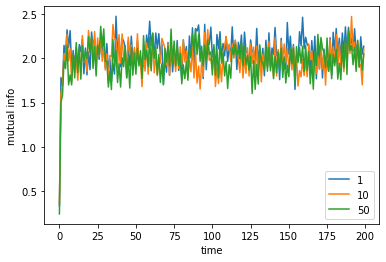

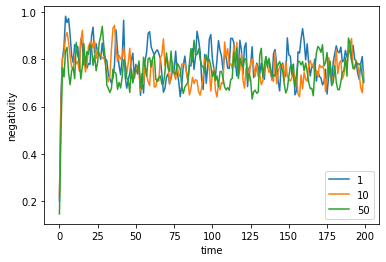

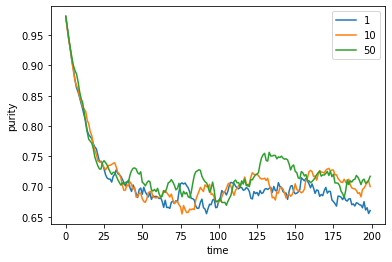

In [110]:
avgedMI_dynamics=np.zeros([3, steps_N])
avgedNeg_dynamics = np.zeros([3, steps_N])
avgedpurity_dynamics = np.zeros([3, steps_N])

for (n,p) in enumerate(dt1List):
    avgedMI_dynamics[n] = np.average(mutualInfoList_dt1_check[p],axis=0)    
    avgedNeg_dynamics[n] = np.average(negativityList_dt1_check[p],axis=0)   
    avgedpurity_dynamics[n] = np.average(purityList_dt1_check[p],axis=0)    

for (n,p) in enumerate(dt1List):
    plt.plot(avgedMI_dynamics[n])
    
plt.xlabel('time')
plt.ylabel('mutual info')
plt.legend(dt1List)

plt.figure()
for (n,p) in enumerate(dt1List):
    plt.plot(avgedNeg_dynamics[n])
plt.xlabel('time')
plt.ylabel('negativity')
plt.legend(dt1List)



plt.figure()
for (n,p) in enumerate(dt1List):
    plt.plot(avgedpurity_dynamics[n])
plt.xlabel('time')
plt.ylabel('purity')
plt.legend(dt1List)


#steps = temp.shape[1]//5
#avgedMI_steady_0[n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])


In [23]:
dt2=5
steps_N = 200
jumpOp_global = S_Z
p=0.15
r=1e-3
N=6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 40

S1List_no_dt = np.zeros([ens_N,steps_N])
S2List_no_dt = np.zeros([ens_N,steps_N])
StotList_no_dt = np.zeros([ens_N,steps_N])
mutualInfoList_no_dt = np.zeros([ens_N,steps_N])
purityList_no_dt = np.zeros([ens_N,steps_N])
negativityList_no_dt = np.zeros([ens_N,steps_N])
print('evolve unitarily (discrete)', 's; dissipate for',dt2, 's.')

startTime = time.time()

for j in range(ens_N):
    S1List_no_dt[j,:], S2List_no_dt[j,:], StotList_no_dt[j,:], mutualInfoList_no_dt[j,:], purityList_no_dt[j,:], negativityList_no_dt[j,:] = combinedRoutine_1(
                                initRho = state0rho,
                                Nqubit = N,
                                rate = r,
                                probMsm = p,
                                dt2 = dt2,                                                                                     
                                jumpOp = jumpOp_global,
                                steps = steps_N,
                                debug = False)
print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)



evolve unitarily (discrete) s; dissipate for 5 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:391: ComplexWarning: Casting complex values to real discards the imaginary part


run time for probability  0.15  = 1129.9801409244537


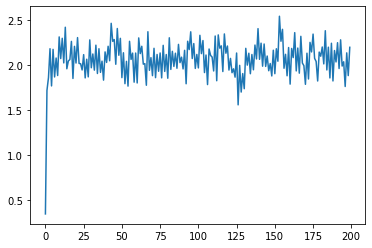

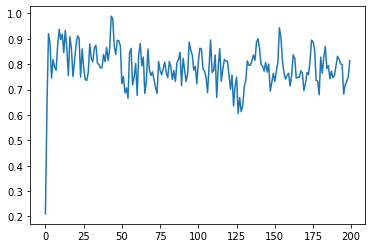

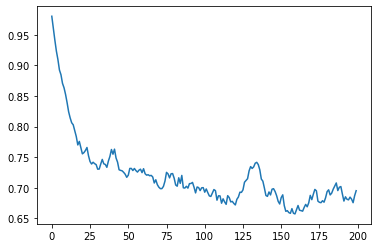

In [22]:
avgedMI_no_dt = np.average(mutualInfoList_no_dt,axis=0)    
avgedNeg_no_dt = np.average(negativityList_no_dt,axis=0)   
avgedpurity_no_dt= np.average(purityList_no_dt,axis=0)  

plt.figure()
plt.plot(avgedMI_no_dt)

plt.figure()
plt.plot(avgedNeg_no_dt)

plt.figure()
plt.plot(avgedpurity_no_dt)


In [111]:
# different set of parameters check the ratio between dt1/dt2
# i.e. the unitary time / the dissipative time 
# guess: larger ratio leads to larger mutual info, negativity and purity

t_total = 1300
dt1 = 5 
dt2List = [1,10,50] # so 1/5, twice, and 10 times larger than dt2
steps_N = 200 #int(t_total/(dt1+dt2))
jumpOp_global = S_Z
p = 0.15
r = 1e-3
N = 6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 50

In [112]:
mutualInfoList_dt2_check = {}
purityList_dt2_check = {}
negativityList_dt2_check = {}


for dt2 in dt2List:

    S1List = np.zeros([ens_N,steps_N])
    S2List = np.zeros([ens_N,steps_N])
    StotList = np.zeros([ens_N,steps_N])
    mutualInfoList_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    purityList_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    negativityList_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

    startTime = time.time()

    for j in range(ens_N):
        S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList_dt2_check[dt2][j,:], purityList_dt2_check[dt2][j,:], negativityList_dt2_check[dt2][j,:] = combinedRoutine(
                                    initRho = state0rho,
                                    Nqubit = N,
                                    rate = r,
                                    probMsm = p,
                                    dt1 = dt1,
                                    dt2 = dt2,                                                                                     
                                    jumpOp = jumpOp_global,
                                    steps = steps_N,
                                    debug = False)
    print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve unitarily for 5 s; dissipate for 1 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:308: ComplexWarning: Casting complex values to real discards the imaginary part


run time for probability  0.15  = 1269.7371327877045
evolve unitarily for 5 s; dissipate for 10 s.
run time for probability  0.15  = 1273.4818708896637
evolve unitarily for 5 s; dissipate for 50 s.
run time for probability  0.15  = 1263.6632730960846


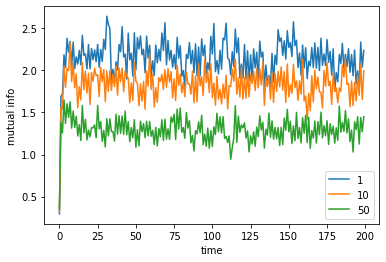

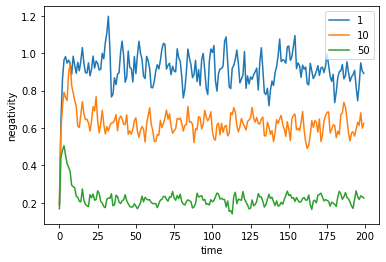

In [157]:
steps_N = 200
avgedMI_dynamics=np.zeros([3, steps_N])
avgedNeg_dynamics = np.zeros([3, steps_N])
avgedpurity_dynamics = np.zeros([3, steps_N])

for (n,p) in enumerate(dt2List):
    avgedMI_dynamics[n] = np.average(mutualInfoList_dt2_check[p],axis=0)    
    avgedNeg_dynamics[n] = np.average(negativityList_dt2_check[p],axis=0)   
    avgedpurity_dynamics[n] = np.average(purityList_dt2_check[p],axis=0)    

for (n,p) in enumerate(dt2List):
    plt.plot(avgedMI_dynamics[n])
    
plt.xlabel('time')
plt.ylabel('mutual info')
plt.legend(dt1List)

plt.figure()
for (n,p) in enumerate(dt2List):
    plt.plot(avgedNeg_dynamics[n])
plt.xlabel('time')
plt.ylabel('negativity')
plt.legend(dt1List)



#steps = temp.shape[1]//5
#avgedMI_steady_0[n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])


In [15]:
def monoExp(x, m, t, b):
    return m * np.exp(-t * x) + b

In [140]:
import scipy

0.08994453384451004 0.07320005888786195 0.9186370799901508
0.4572213595061494 0.1144510082840547 0.5639255181491472
0.7881267509656632 0.2672551086804135 0.22017456156557852


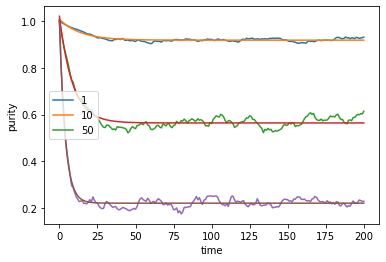

In [159]:
# perform the fit

plt.figure()
for (n,p) in enumerate(dt2List):
    xs = np.array([n for n in range(len(avgedpurity_dynamics[n])+1) ])
    ys = np.concatenate([[1],avgedpurity_dynamics[n]])
    p0 = (1, p*1e-3, 5/p) # start with values near those we expect
    params, cv = scipy.optimize.curve_fit(monoExp, xs, ys, p0)
    m, t, b = params
    print(m,t,b)


    plt.plot(xs,ys)
    plt.plot(xs,monoExp(xs, m, t, b))
    #plt.plot(np.exp(-p*r * np.array([n for n in range(len(avgedpurity_dynamics[n])) ])))
plt.xlabel('time')
plt.ylabel('purity')
plt.legend(dt1List)


The time of dissipation, not the unitary, affects the value of mutual info, negativities and purity of the steady state.

In [114]:
# different set of parameters check the ratio between dt1/dt2
# i.e. the unitary time / the dissipative time 
# guess: larger ratio leads to larger mutual info, negativity and purity

t_total = 1300
dt1 = 5 
dt2List = [1,10,50] # so 1/5, twice, and 10 times larger than dt2
steps_N = 150 #int(t_total/(dt1+dt2))
jumpOp_global = S_Z
p = 0.15
r = 1e-2
N = 6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 50

In [117]:
mutualInfoList_r2_dt2_check = {}
purityList_r2_dt2_check = {}
negativityList_r2_dt2_check = {}


for dt2 in dt2List:

    S1List = np.zeros([ens_N,steps_N])
    S2List = np.zeros([ens_N,steps_N])
    StotList = np.zeros([ens_N,steps_N])
    mutualInfoList_r2_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    purityList_r2_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    negativityList_r2_dt2_check[dt2] = np.zeros([ens_N,steps_N])
    
    startTime = time.time()
    print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

    for j in range(ens_N):
        S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList_r2_dt2_check[dt2][j,:], purityList_r2_dt2_check[dt2][j,:], negativityList_r2_dt2_check[dt2][j,:] = combinedRoutine(
                                    initRho = state0rho,
                                    Nqubit = N,
                                    rate = r,
                                    probMsm = p,
                                    dt1 = dt1,
                                    dt2 = dt2,                                                                                     
                                    jumpOp = jumpOp_global,
                                    steps = steps_N,
                                    debug = False)
    print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve unitarily for 5 s; dissipate for 1 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:308: ComplexWarning: Casting complex values to real discards the imaginary part


run time for probability  0.15  = 1031.6582310199738
evolve unitarily for 5 s; dissipate for 10 s.
run time for probability  0.15  = 1103.4302229881287
evolve unitarily for 5 s; dissipate for 50 s.
run time for probability  0.15  = 1029.9873306751251


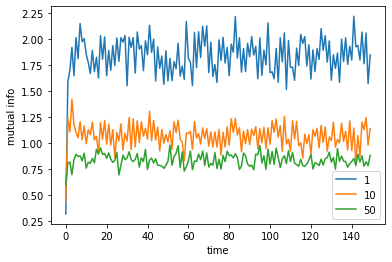

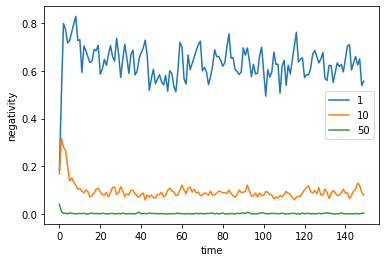

In [161]:
steps_N=150
avgedMI_dynamics=np.zeros([3, steps_N])
avgedNeg_dynamics = np.zeros([3, steps_N])
avgedpurity_dynamics = np.zeros([3, steps_N])

for (n,p) in enumerate(dt2List):
    avgedMI_dynamics[n] = np.average(mutualInfoList_r2_dt2_check[p],axis=0)    
    avgedNeg_dynamics[n] = np.average(negativityList_r2_dt2_check[p],axis=0)   
    avgedpurity_dynamics[n] = np.average(purityList_r2_dt2_check[p],axis=0)    

for (n,p) in enumerate(dt2List):
    plt.plot(avgedMI_dynamics[n])
    
plt.xlabel('time')
plt.ylabel('mutual info')
plt.legend(dt1List)

plt.figure()
for (n,p) in enumerate(dt2List):
    plt.plot(avgedNeg_dynamics[n])
plt.xlabel('time')
plt.ylabel('negativity')
plt.legend(dt1List)


#steps = temp.shape[1]//5
#avgedMI_steady_0[n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])


0.45344119244281383 0.10086049062104775 0.5569714455321468
0.8557274709154084 0.4488948047255326 0.14253245254530197
0.9410582146339047 1.4989837643876072 0.05769121797770107


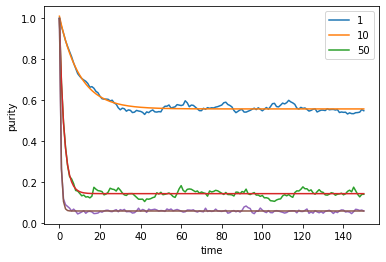

In [165]:
# perform the fit

plt.figure()
for (n,p) in enumerate(dt2List):
    xs = np.array([n for n in range(len(avgedpurity_dynamics[n])+1) ])
    ys = np.concatenate([[1],avgedpurity_dynamics[n]])
    p0 = (1, p*1e-2, 2/p) # start with values near those we expect
    params, cv = scipy.optimize.curve_fit(monoExp, xs, ys, p0)
    m, t, b = params
    print(m,t,b)

    plt.plot(xs,ys)
    plt.plot(xs,monoExp(xs, m, t, b))
    #plt.plot(np.exp(-p*r * np.array([n for n in range(len(avgedpurity_dynamics[n])) ])))
plt.xlabel('time')
plt.ylabel('purity')
plt.legend(dt1List)



2.804032974906919 0.10986378971039913


Text(0.5, 1.0, 'probability of msm = 0.15')

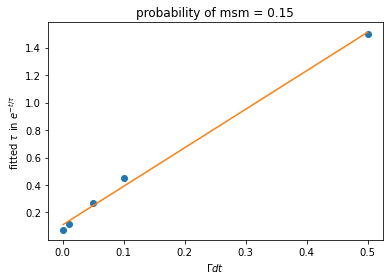

In [20]:
plt.plot(np.array([1e-3, 1e-2,5e-2, 1e-1,5e-1]), 
         np.array([0.07320005888786195, 0.1144510082840547,0.2672551086804135, 0.4488948047255326, 1.4989837643876072]),
         'o')
k,m = np.polyfit(np.array([1e-3, 1e-2,5e-2, 1e-1,5e-1]),np.array([0.07320005888786195, 0.1144510082840547,0.2672551086804135, 0.4488948047255326, 1.4989837643876072]),1)

dom = np.linspace(1e-3,5e-1)
plt.plot(dom, k*dom + m)
print(k,m)

plt.xlabel(r'$\Gamma dt $')
plt.ylabel(r'fitted $\tau$ in $e^{-t/\tau}$')
plt.title('probability of msm = 0.15')


In [30]:
rates=np.logspace(-4,-1,4)
MeanLifeTime=1/(2*2.8*(rates)+0.1)
print(rates,MeanLifeTime)

[0.0001 0.001  0.01   0.1   ] [9.94431185 9.46969697 6.41025641 1.51515152]


In [154]:
1e-3, 1e-2, 5e-2
0.08994453384451004 0.07320005888786195 0.9186370799901508
0.4572213595061494 0.1144510082840547 0.5639255181491472
0.7881267509656632 0.2672551086804135 0.22017456156557852

1e-2, 1e-1, 5e-1
0.45344119244281383 0.10086049062104775 0.5569714455321468
0.8557274709154084 0.4488948047255326 0.14253245254530197
0.9410582146339047 1.4989837643876072 0.05769121797770107


array([1.        , 0.99597182, 0.99191697, 0.98813572, 0.98427786,
       0.98111772, 0.97774847, 0.97459986, 0.97281551, 0.96971199,
       0.96745702, 0.96594233, 0.96396512, 0.96109174, 0.95832687,
       0.95562671, 0.95339778, 0.95017625, 0.94626957, 0.94494131,
       0.94438773, 0.94214535, 0.93863784, 0.93617064, 0.93229884,
       0.92811986, 0.9283483 , 0.92902275, 0.92715844, 0.92547188,
       0.92294891, 0.92186132, 0.91889496, 0.91728588, 0.91688767,
       0.91615759, 0.92224077, 0.92078814, 0.92445477, 0.92511576,
       0.92119175, 0.92541304, 0.92418907, 0.91834654, 0.91783139,
       0.91979012, 0.91586713, 0.91698082, 0.9176869 , 0.91503015,
       0.91277804, 0.91825434, 0.91920902, 0.9159649 , 0.91439469,
       0.91292589, 0.91318174, 0.90988675, 0.90726435, 0.90534498,
       0.90344724, 0.90658729, 0.91355827, 0.91522087, 0.91387573,
       0.91323101, 0.91284126, 0.91040816, 0.91661166, 0.91723785,
       0.91545988, 0.91701356, 0.91678105, 0.91508514, 0.91452

In [ ]:
# different set of parameters check the ratio between dt1/dt2
# i.e. the unitary time / the dissipative time 
# guess: larger ratio leads to larger mutual info, negativity and purity

t_total = 1300
dt1 = 5 
dt2List = [.1,1,5] # so 1/5, twice, and 10 times larger than dt2
steps_N = 150 #int(t_total/(dt1+dt2))
jumpOp_global = S_Z
p = 0.15
r = 1e-1
N = 6

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
ens_N = 50

mutualInfoList_r2dt2_check = {}
purityList_r2dt2_check = {}
negativityList_r2dt2_check = {}


for dt2 in dt2List:

    S1List = np.zeros([ens_N,steps_N])
    S2List = np.zeros([ens_N,steps_N])
    StotList = np.zeros([ens_N,steps_N])
    mutualInfoList_r2dt2_check[dt2] = np.zeros([ens_N,steps_N])
    purityList_r2dt2_check[dt2] = np.zeros([ens_N,steps_N])
    negativityList_r2dt2_check[dt2] = np.zeros([ens_N,steps_N])
    
    startTime = time.time()
    print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

    for j in range(ens_N):
        S1List[j,:], S2List[j,:], StotList[j,:], mutualInfoList_r2dt2_check[dt2][j,:], purityList_r2dt2_check[dt2][j,:], negativityList_r2dt2_check[dt2][j,:] = combinedRoutine(
                                    initRho = state0rho,
                                    Nqubit = N,
                                    rate = r,
                                    probMsm = p,
                                    dt1 = dt1,
                                    dt2 = dt2,                                                                                     
                                    jumpOp = jumpOp_global,
                                    steps = steps_N,
                                    debug = False)
    print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


In [6]:
dt1 = 5 
dt2 = 5 # so 1/5, twice, and 10 times larger than dt2
steps_N = 150 #int(t_total/(dt1+dt2))
jumpOp_global = S_Z
p = 0.15
r = 1e-1
N = 6
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

startTime = time.time()
print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

S1, S2, Stot, mutualInfo, purity, negativity = combinedRoutine(
                            initRho = state0rho,
                            Nqubit = N,
                            rate = r,
                            probMsm = p,
                            dt1 = dt1,
                            dt2 = dt2,                                                                                     
                            jumpOp = jumpOp_global,
                            steps = steps_N,
                            debug = False)
#print(S1, S2, Stot, mutualInfo, purity, negativity)
print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)

startTime = time.time()
print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')
S1, S2, Stot, mutualInfo, purity, negativity = combinedRoutine_test(
                            initRho = state0rho,
                            Nqubit = N,
                            rate = r,
                            probMs = p,
                            dt1 = dt1,
                            dt2 = dt2,                                                                                     
                            jumpOp = jumpOp_global,
                            steps = steps_N,
                            debug = False)
#print(S1, S2, Stot, mutualInfo, purity, negativity)
print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve unitarily for 5 s; dissipate for 5 s.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:308: ComplexWarning: Casting complex values to real discards the imaginary part


[1.8537466  2.51891998 3.54882676 3.95095963 2.98948615 2.99711692
 3.58976984 3.58126158 2.78981884 2.77682255 2.55685743 1.45848
 1.62714429 3.50850691 3.81559943 2.97709142 2.41298731 3.58006541
 3.88213535 3.75092867 2.91266671 2.92509306 3.46136659 1.91090417
 3.22759713 3.86124836 2.96461879 2.6727294  1.83991219 3.49839351
 3.88250898 3.51053246 2.95764102 1.97971933 3.49860873 2.89273811
 3.63303835 3.86984092 2.97963519 2.98921373 3.68819705 2.97479164
 3.69357976 3.87502654 2.94374024 3.55598469 3.88823612 2.99207765
 3.55756959 1.876231   3.14874985 3.8341588  3.93738124 1.99790834
 3.27746416 2.84259182 3.57085194 1.98853843 3.17359368 2.84161069
 2.50761214 3.5094312  2.88763884 1.98587878 2.5816101  2.82921012
 2.7069449  1.98222056 3.20914508 2.93471723 2.74880555 1.58559802
 2.16535966 0.93777581 1.63576227 3.29821324 2.74675065 3.55364523
 3.86986468 3.98458729 2.99355272 3.70080328 2.93320615 2.75234282
 2.45927482 2.81016395 3.60202276 1.98301878 3.31756674 3.9290461

evolve unitarily for 5 s; dissipate for 5 s.
traj starts.


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:350: ComplexWarning: Casting complex values to real discards the imaginary part


[1.87319182 3.32352278 2.88363046 3.71864159 3.89365863 3.9398851
 2.98293653 1.93915945 2.10255448 2.85353774 3.68590228 3.84659933
 2.93797036 1.96996607 2.48020223 2.74797835 3.62839314 3.90095526
 3.96706669 3.92678906 2.97545045 3.61041757 3.82948501 2.97198224
 3.57938891 3.90531568 3.96736526 2.99598068 3.68468022 3.98694186
 2.99519327 3.70950789 0.99204787 1.99570867 3.080662   3.89973782
 3.97462276 2.92709134 3.5985947  2.91796997 2.60058961 2.746419
 2.51628539 3.61857191 2.90529449 3.49415332 3.77935738 2.9780786
 2.65628712 1.64170573 2.55241488 2.66413008 3.46262822 3.62801429
 3.88469954 3.93935616 2.97319635 3.91197159 2.97153043 3.89122767
 1.92058151 3.16860021 3.68154764 1.97234161 3.16119457 3.81627937
 2.97047055 3.48120992 2.96436308 3.64923499 2.94224827 3.41684423
 2.89847589 3.856005   2.99433654 2.68338238 3.43965816 2.67838003
 2.44708863 3.48936675 3.79113219 3.87986198 3.95567814 1.52160892
 2.15811289 1.97900688 2.28751219 3.17560936 1.93841844 3.20201381

0.00011417328615267174 1.5378874906137634 4.838709677419355


/Users/cathy/anaconda3/lib/python3.7/site-packages/scipy/optimize/minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


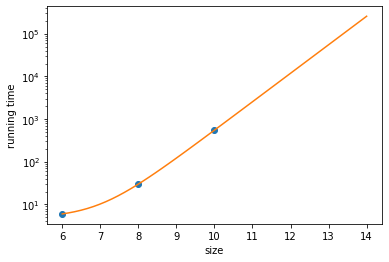

In [27]:
import scipy
def monoExp(x, m, t, b):
    return m * np.exp(t * x) + b

plt.semilogy(np.array([6,8,10]),np.array([6,30,550]),'o')
plt.xlabel('size')
plt.ylabel('running time')
xs = np.array([6,8,10])
ys = np.array([6,30,550])
p0 = (1, 1, 2) # start with values near those we expect
params, cv = scipy.optimize.curve_fit(monoExp, xs, ys, p0)
m, t, b = params
print(m,t,b)

plt.semilogy(np.linspace(6,14),m * np.exp(t * np.linspace(6,14)) + b)

In [26]:
(m * np.exp(t * 14) + b)/3600

71.091049382716